# Análisis exploratorio y limpieza de vuelos

**Proyecto:** predicción de atraso de llegada de vuelos.  
**Asignatura:** Cloud Computing, Diploma en Data Science, Universidad Adolfo Ibáñez.

El objetivo es revisar la calidad de los datos, justificar su limpieza y construir una
base reproducible para clasificación supervisada. La etiqueta `ARRIVAL_DELAY_15`
vale **1** cuando el atraso de llegada es de 15 minutos o más, y **0** en caso contrario.
Se seleccionan predictores conocidos antes de la salida programada.

La población analizada corresponde a vuelos de 2015 no cancelados ni desviados y
con atraso de llegada observado. El alcance queda condicionado a que el vuelo
complete su ruta; no se estiman cancelaciones ni el riesgo total de interrupción.

**Fuentes:** [2015 Flight Delays and Cancellations, USDOT en Kaggle](https://www.kaggle.com/datasets/usdot/flight-delays)
y [definición de atraso de BTS](https://www.transtats.bts.gov/OT_Delay/).
Se registra la huella SHA-256 del archivo local para identificar la versión procesada.

## 1. Configuración y ubicación del archivo original

El archivo de entrada es `flights.csv`; su ubicación se define en `RUTA_CSV`.
La semilla 42 fija el muestreo y la separación de entrenamiento y prueba.
La lectura se realiza en bloques de 200.000 filas y la muestra final contiene
10.000 vuelos. Los CSV preparados se guardan en `data/` y las tablas y gráficos
en `reportes/`.

El entorno de referencia utiliza Python 3.12.14 y las versiones fijadas en
`requirements.txt`. La celda siguiente registra las versiones de la ejecución.

In [1]:
from pathlib import Path
from collections import Counter
import os
import json
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Funciona al abrir el notebook desde la raíz del proyecto o desde notebooks/.
BASE = Path.cwd()
if BASE.name.lower() == 'notebooks':
    BASE = BASE.parent

# Si el CSV está en otra ubicación, reemplaza esta asignación por Path(r"tu ruta").
# FLIGHTS_CSV permite indicar una ruta externa sin guardarla dentro del notebook.
RUTA_CSV = Path(os.environ.get('FLIGHTS_CSV', str(BASE / 'data/raw/flights.csv')))
if not RUTA_CSV.is_file():
    raise FileNotFoundError(
        'No se encontró flights.csv. Colócalo en data/raw/ o ajusta RUTA_CSV en esta celda.'
    )

SEMILLA = 42
TAMANO_BLOQUE = 200_000
TAMANO_MUESTRA = 10_000
DATOS = BASE / 'data'
REPORTES = BASE / 'reportes'
GRAFICOS = REPORTES / 'graficos'
DATOS.mkdir(exist_ok=True)
GRAFICOS.mkdir(parents=True, exist_ok=True)
ARCHIVO_LIMPIO = DATOS / 'flights_limpio.csv'
assert RUTA_CSV.resolve() != ARCHIVO_LIMPIO.resolve(), 'La entrada debe ser el CSV original.'

versiones = {'python':platform.python_version(), 'pandas':pd.__version__,
            'numpy':np.__version__, 'matplotlib':matplotlib.__version__}
print('Versiones:', versiones)
print('Archivo original:', RUTA_CSV.name)
print('Tamaño original (MB):', round(RUTA_CSV.stat().st_size / 1_000_000, 2))
plt.rcParams.update({'figure.figsize':(9,5), 'font.size':11})

Versiones: {'python': '3.12.10', 'pandas': '3.0.1', 'numpy': '2.3.5', 'matplotlib': '3.10.8'}
Archivo original: flights.csv
Tamaño original (MB): 592.41


## 2. Definir predictores y revisar la estructura

Se seleccionan tres predictores categóricos: aerolínea, aeropuerto de origen y
aeropuerto de destino. Los seis predictores numéricos describen el calendario,
la salida programada, la duración programada y la distancia.

`ARRIVAL_DELAY` se conserva únicamente para construir y auditar la etiqueta.
`SOURCE_ROW` y `FLIGHT_DATE` permiten rastrear los registros, pero no forman parte
de los nueve predictores propuestos. La hora original HHMM se convertirá a minutos.

In [2]:
CATEGORICAS = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
NUMERICAS = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE_MIN',
             'SCHEDULED_TIME', 'DISTANCE']
FEATURES = CATEGORICAS + NUMERICAS
OBJETIVO = 'ARRIVAL_DELAY_15'
TEXTO = CATEGORICAS + ['TAIL_NUMBER', 'CANCELLATION_REASON']

columnas = pd.read_csv(RUTA_CSV, nrows=0).columns.tolist()
requeridas = set(TEXTO + ['YEAR','MONTH','DAY','DAY_OF_WEEK','SCHEDULED_DEPARTURE',
                          'SCHEDULED_TIME','DISTANCE','ARRIVAL_DELAY','CANCELLED','DIVERTED'])
faltantes = requeridas - set(columnas)
assert not faltantes, f'Faltan columnas de la fuente: {faltantes}'
# Tipos uniformes para que la lectura y las huellas sean consistentes entre bloques.
tipos = {c:'string' if c in TEXTO else 'float64' for c in columnas}
vista = pd.read_csv(RUTA_CSV, nrows=5, dtype=tipos)
print('Columnas originales:', len(columnas))
print('Lista de columnas:', columnas)
print(vista[['YEAR','MONTH','DAY','AIRLINE','ORIGIN_AIRPORT',
             'DESTINATION_AIRPORT','SCHEDULED_DEPARTURE','ARRIVAL_DELAY']].to_string(index=False))

Columnas originales: 31
Lista de columnas: ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
  YEAR  MONTH  DAY AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ARRIVAL_DELAY
2015.0    1.0  1.0      AS            ANC                 SEA                  5.0          -22.0
2015.0    1.0  1.0      AA            LAX                 PBI                 10.0           -9.0
2015.0    1.0  1.0      US            SFO                 CLT                 20.0            5.0
2015.0    1.0  1.0      AA            LAX                 MIA               

## 3. Reglas de limpieza y tratamiento de faltantes

Se aplican reglas fijas de calidad, sin aprender umbrales a partir del conjunto de prueba:

1. Normalizar espacios y mayúsculas en categorías.
2. Separar cancelaciones y desvíos, que quedan fuera de la población definida.
3. Excluir filas sin atraso observado: imputar la etiqueta inventaría respuestas.
4. Validar fecha, día de semana, hora programada, distancia y duración positivas.
5. Validar formatos de aerolínea y aeropuertos, conservando sus códigos como texto.
6. Convertir la salida programada a minutos y crear la etiqueta binaria.

No se hace `dropna()` sobre las 31 columnas: faltantes en causas de cancelación
o atraso pueden significar que el campo no aplica. Esas columnas tampoco se usan
para predecir antes de la salida. Los atrasos negativos son llegadas anticipadas;
los atrasos extremos se conservan si cumplen las reglas de calidad.

Cada fila excluida recibe un único motivo: la primera regla que incumple.

In [3]:
def limpiar_bloque(df, conteos):
    """Devuelve vuelos elegibles. Cada descarte se cuenta una sola vez."""
    df = df.copy()
    for col in CATEGORICAS:
        df[col] = df[col].str.strip().str.upper().replace('', pd.NA)

    def filtrar(mascara, motivo):
        nonlocal df
        mascara = mascara.fillna(False)
        conteos[motivo] += int((~mascara).sum())
        df = df.loc[mascara].copy()

    filtrar(df.CANCELLED.eq(0), 'cancelado_o_estado_invalido')
    filtrar(df.DIVERTED.eq(0), 'desviado_o_estado_invalido')
    filtrar(np.isfinite(df.ARRIVAL_DELAY), 'sin_atraso_observado')
    df['FLIGHT_DATE'] = pd.to_datetime(
        df[['YEAR', 'MONTH', 'DAY']].rename(
            columns={'YEAR':'year', 'MONTH':'month', 'DAY':'day'}), errors='coerce')
    filtrar(df.FLIGHT_DATE.notna(), 'fecha_invalida')
    filtrar(df.DAY_OF_WEEK.eq(df.FLIGHT_DATE.dt.dayofweek + 1), 'dia_semana_inconsistente')

    # 0530 representa 05:30; no equivale a 530 minutos.
    hora = df.SCHEDULED_DEPARTURE
    hora_valida = (hora.between(0, 2359) & hora.mod(100).lt(60)
                   & hora.mod(1).eq(0)) | hora.eq(2400)
    filtrar(hora_valida, 'hora_programada_invalida')
    hora = df.SCHEDULED_DEPARTURE
    df['SCHEDULED_DEPARTURE_MIN'] = (hora.floordiv(100) * 60 + hora.mod(100)).astype(int)
    # Se conserva 2400 como 1440: final del día programado, sin cambiar la fecha.
    filtrar(np.isfinite(df.DISTANCE) & df.DISTANCE.gt(0)
            & np.isfinite(df.SCHEDULED_TIME) & df.SCHEDULED_TIME.gt(0),
            'distancia_o_duracion_invalida')
    filtrar(df[CATEGORICAS].notna().all(axis=1), 'categoria_faltante')
    filtrar(df.AIRLINE.str.fullmatch(r'[A-Z0-9]{2}'), 'aerolinea_formato_invalido')
    for col in ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
        filtrar(df[col].str.fullmatch(r'[A-Z]{3}|\d{5}'), col.lower() + '_formato_invalido')
        # Conservamos ambos sistemas. No se inventa una equivalencia entre códigos.
        numerico = df[col].str.fullmatch(r'\d{5}')
        df[col] = np.where(numerico, 'BTS:' + df[col], 'IATA:' + df[col])
    df[OBJETIVO] = df.ARRIVAL_DELAY.ge(15).astype(int)
    for col in ['MONTH', 'DAY', 'DAY_OF_WEEK']:
        df[col] = df[col].astype(int)
    df['FLIGHT_DATE'] = df.FLIGHT_DATE.dt.strftime('%Y-%m-%d')
    return df[['SOURCE_ROW', 'FLIGHT_DATE'] + FEATURES + ['ARRIVAL_DELAY', OBJETIVO]]

## 4. Recorrer todo el CSV, limpiar y guardar la base completa

Antes de descartar registros se cuentan los nulos de todas las columnas y los formatos
de aeropuerto por mes. Los duplicados se detectan con una huella de la fila original
completa, dentro y entre bloques. La huella de 64 bits es una comprobación práctica
con un riesgo teórico de colisiones; no se eliminan vuelos por compartir ruta u horario.

`SOURCE_ROW` identifica la posición del registro original, con el encabezado contado
como primera línea. Cada bloque limpio se añade a `data/flights_limpio.csv`.

Para la muestra se asigna una prioridad aleatoria uniforme a cada fila elegible y se
conservan las 10.000 menores. Así todas las filas elegibles tienen la misma oportunidad
de selección, sin limitar la muestra al inicio del archivo, ordenado por fecha.
La prioridad no usa la etiqueta ni balancea artificialmente las clases.

In [4]:
conteos = Counter()
nulos = pd.Series(0, index=columnas, dtype='int64')
vistos = np.array([], dtype='uint64')
rng = np.random.default_rng(SEMILLA)
candidatos = pd.DataFrame()
perfil_meses = []
total = limpios = 0
encabezado_escrito = False
ARCHIVO_LIMPIO.write_text('', encoding='utf-8')

for numero_bloque, df in enumerate(pd.read_csv(RUTA_CSV, dtype=tipos, chunksize=TAMANO_BLOQUE), start=1):
    nulos += df.isna().sum()
    mes = df.groupby('MONTH').size().rename('filas').to_frame()
    mes['origen_codigo_numerico'] = df.ORIGIN_AIRPORT.str.fullmatch(r'\d+').groupby(df.MONTH).sum()
    mes['destino_codigo_numerico'] = df.DESTINATION_AIRPORT.str.fullmatch(r'\d+').groupby(df.MONTH).sum()
    perfil_meses.append(mes)

    hashes = pd.util.hash_pandas_object(df, index=False).to_numpy()
    duplicada = pd.Series(hashes).duplicated().to_numpy() | np.isin(hashes, vistos)
    conteos['duplicados_por_huella'] += int(duplicada.sum())
    vistos = np.concatenate([vistos, hashes[~duplicada]])
    df['SOURCE_ROW'] = np.arange(total + 2, total + len(df) + 2)
    total += len(df)
    limpio = limpiar_bloque(df.loc[~duplicada], conteos)

    assert limpio[FEATURES + [OBJETIVO]].notna().all().all()
    assert limpio[OBJETIVO].eq(limpio.ARRIVAL_DELAY.ge(15)).all()
    limpio.to_csv(ARCHIVO_LIMPIO, mode='a', header=not encabezado_escrito, index=False)
    encabezado_escrito = True
    limpios += len(limpio)

    limpio['_prioridad'] = rng.random(len(limpio))
    candidatos = pd.concat([candidatos, limpio], ignore_index=True)
    candidatos = candidatos.nsmallest(TAMANO_MUESTRA, '_prioridad')
    if numero_bloque == 1 or numero_bloque % 5 == 0:
        print(f'Leídas: {total:,}; conservadas: {limpios:,}', flush=True)

assert total > 0 and limpios >= TAMANO_MUESTRA
assert limpios + sum(conteos.values()) == total
print(f'Lectura completa: {total:,} filas; base limpia: {limpios:,} filas.')
del df, limpio, vistos, hashes, duplicada

Leídas: 200,000; conservadas: 194,401
Leídas: 1,000,000; conservadas: 957,394
Leídas: 2,000,000; conservadas: 1,946,636
Leídas: 3,000,000; conservadas: 2,927,797
Leídas: 4,000,000; conservadas: 3,915,583
Leídas: 5,000,000; conservadas: 4,908,741
Leídas: 5,819,079; conservadas: 5,714,008
Lectura completa: 5,819,079 filas; base limpia: 5,714,008 filas.


## 5. Resultados de calidad: nulos y códigos por mes

Los siguientes conteos corresponden al **CSV original completo**, antes de los filtros.
Un alto porcentaje de nulos no es suficiente para decidir borrar una columna o una fila:
primero se considera su significado y si estará disponible al momento de la predicción.

In [5]:
tabla_nulos = pd.DataFrame({'nulos':nulos, 'porcentaje':100*nulos/total})
tabla_nulos.to_csv(REPORTES / 'nulos_original.csv')
print(tabla_nulos.sort_values('porcentaje',ascending=False).round(3).to_string())

tabla_meses = pd.concat(perfil_meses).groupby(level=0).sum()
tabla_meses.index = tabla_meses.index.astype(int)
tabla_meses.to_csv(REPORTES / 'meses_original.csv')
print('Formatos de aeropuerto por mes:')
print(tabla_meses.to_string())

                       nulos  porcentaje
CANCELLATION_REASON  5729195      98.455
LATE_AIRCRAFT_DELAY  4755640      81.725
WEATHER_DELAY        4755640      81.725
AIRLINE_DELAY        4755640      81.725
AIR_SYSTEM_DELAY     4755640      81.725
SECURITY_DELAY       4755640      81.725
ELAPSED_TIME          105071       1.806
AIR_TIME              105071       1.806
ARRIVAL_DELAY         105071       1.806
WHEELS_ON              92513       1.590
TAXI_IN                92513       1.590
ARRIVAL_TIME           92513       1.590
WHEELS_OFF             89047       1.530
TAXI_OUT               89047       1.530
DEPARTURE_TIME         86153       1.481
DEPARTURE_DELAY        86153       1.481
TAIL_NUMBER            14721       0.253
SCHEDULED_TIME             6       0.000
DESTINATION_AIRPORT        0       0.000
DAY                        0       0.000
DAY_OF_WEEK                0       0.000
AIRLINE                    0       0.000
FLIGHT_NUMBER              0       0.000
MONTH           

En esta fuente, octubre utiliza códigos numéricos de aeropuerto. Se conservan como
`BTS:xxxxx`, mientras los códigos de tres letras se conservan como `IATA:XXX`.
No se elimina octubre ni se inventa una equivalencia entre ambos sistemas.
Un aeropuerto puede quedar representado por dos categorías: esta limitación debe
tenerse en cuenta al interpretar patrones por aeropuerto o por mes.

La hora de salida programada se transforma desde HHMM: 0530 equivale a 330 minutos.
El valor 2400, si aparece, se conserva como 1440 minutos del día programado.
No se restan horas locales de origen y destino, porque pueden tener zonas horarias distintas.

## 6. Auditoría de filas excluidas

La tabla permite reconstruir el paso desde el archivo original hasta el limpio.
Como los motivos son excluyentes, sumar las exclusiones no cuenta una fila dos veces.
Los faltantes en campos operativos que no se usan como predictores no provocan descartes.

In [6]:
pasos = []
restantes = total
for motivo, cantidad in conteos.items():
    restantes -= cantidad
    pasos.append({'regla':motivo, 'filas_excluidas':cantidad, 'filas_restantes':restantes})
auditoria = pd.DataFrame(pasos)
auditoria.to_csv(REPORTES / 'auditoria_limpieza.csv', index=False)
assert restantes == limpios
print(auditoria.to_string(index=False))
print(f'Conservado: {100*limpios/total:.2f}% del original.')

                               regla  filas_excluidas  filas_restantes
               duplicados_por_huella                0          5819079
         cancelado_o_estado_invalido            89884          5729195
          desviado_o_estado_invalido            15187          5714008
                sin_atraso_observado                0          5714008
                      fecha_invalida                0          5714008
            dia_semana_inconsistente                0          5714008
            hora_programada_invalida                0          5714008
       distancia_o_duracion_invalida                0          5714008
                  categoria_faltante                0          5714008
          aerolinea_formato_invalido                0          5714008
     origin_airport_formato_invalido                0          5714008
destination_airport_formato_invalido                0          5714008
Conservado: 98.19% del original.


## 7. Muestreo y separación de entrenamiento y prueba

Se ordenan las 10.000 filas seleccionadas por su posición original y se toma el
80% de cada clase para entrenamiento y el resto para prueba, con semilla 42.
Se obtienen **8.000 vuelos de entrenamiento y 2.000 de prueba**.

El EDA detallado de distribuciones y relaciones con la etiqueta utiliza únicamente
entrenamiento. El conjunto de prueba se reserva para la evaluación predictiva;
en esta etapa solo se comprueban su integridad y separación.

In [7]:
muestra = candidatos.drop(columns='_prioridad').sort_values('SOURCE_ROW').reset_index(drop=True)
del candidatos
grupos_train = []
for _, grupo in muestra.groupby(OBJETIVO):
    grupos_train.append(grupo.sample(frac=0.8, random_state=SEMILLA))
train = pd.concat(grupos_train).sort_values('SOURCE_ROW')
test = muestra.drop(index=train.index).sort_values('SOURCE_ROW')

assert len(train) + len(test) == len(muestra)
assert set(train.SOURCE_ROW).isdisjoint(test.SOURCE_ROW)
assert muestra.SOURCE_ROW.is_unique
assert set(muestra[OBJETIVO]) == {0,1}
assert muestra[FEATURES + [OBJETIVO]].notna().all().all()
assert muestra[OBJETIVO].eq(muestra.ARRIVAL_DELAY.ge(15)).all()
assert len(muestra) >= 500 and len(FEATURES) >= 4

muestra.to_csv(DATOS / 'flights_muestra.csv', index=False)
train.to_csv(DATOS / 'train.csv', index=False)
test.to_csv(DATOS / 'test.csv', index=False)
n_train, n_test = len(train), len(test)
print('Muestra:', len(muestra), '| Train:', n_train, '| Test:', n_test)

Muestra: 10000 | Train: 8000 | Test: 2000


## 8. Inspeccionar los datos preparados y sus tipos

Las categorías permanecen como texto. No se aplican codificación, imputación aprendida
ni escalado sobre toda la base. Las transformaciones que aprende el modelo se ajustan
en su pipeline, exclusivamente con entrenamiento.

La base preparada contiene trece columnas: nueve predictores, una etiqueta y tres
columnas de auditoría. La lista explícita de predictores impide incluir accidentalmente
el atraso real en la entrada del modelo.

In [8]:
print(train.head().to_string(index=False))
calidad_train = pd.DataFrame({
    'tipo':train.dtypes.astype(str),
    'nulos':train.isna().sum(),
    'valores_distintos':train.nunique(),
})
calidad_train.to_csv(REPORTES / 'calidad_train.csv')
print(calidad_train.to_string())

 SOURCE_ROW FLIGHT_DATE AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT  MONTH  DAY  DAY_OF_WEEK  SCHEDULED_DEPARTURE_MIN  SCHEDULED_TIME  DISTANCE  ARRIVAL_DELAY  ARRIVAL_DELAY_15
        815  2015-01-01      B6       IATA:JFK            IATA:BUF      1    1            4                      415            94.0     301.0          -22.0                 0
        818  2015-01-01      EV       IATA:MFE            IATA:IAH      1    1            4                      415            74.0     316.0          -13.0                 0
       1251  2015-01-01      WN       IATA:SJU            IATA:FLL      1    1            4                      450           170.0    1046.0           -3.0                 0
       1965  2015-01-01      UA       IATA:ORD            IATA:DEN      1    1            4                      505           160.0     888.0           76.0                 1
       3669  2015-01-01      AS       IATA:SEA            IATA:OAK      1    1            4                      620    

## 9. Estadísticas descriptivas y valores extremos

Se revisan mínimo, máximo, media, mediana y percentiles. La media puede verse afectada
por atrasos prolongados, por lo que se interpreta junto con la mediana y los percentiles.
Un valor extremo no demuestra por sí mismo que exista un error: no se aplican recortes
por IQR ni winsorización que eliminen casos válidos del problema.

In [9]:
estadisticas = train[NUMERICAS + ['ARRIVAL_DELAY']].describe(
    percentiles=[0.01,0.25,0.50,0.75,0.99]).T
estadisticas.to_csv(REPORTES / 'estadisticas_train.csv')
print(estadisticas.round(3).to_string())

                          count     mean      std   min     1%    25%    50%     75%      99%     max
MONTH                    8000.0    6.506    3.380   1.0    1.0    4.0    7.0     9.0    12.00    12.0
DAY                      8000.0   15.681    8.814   1.0    1.0    8.0   16.0    23.0    31.00    31.0
DAY_OF_WEEK              8000.0    3.945    1.997   1.0    1.0    2.0    4.0     6.0     7.00     7.0
SCHEDULED_DEPARTURE_MIN  8000.0  808.210  289.507   5.0  330.0  555.0  805.0  1049.0  1360.00  1439.0
SCHEDULED_TIME           8000.0  142.320   75.341  30.0   45.0   85.0  123.0   175.0   375.00   562.0
DISTANCE                 8000.0  827.501  609.218  67.0  100.0  376.0  649.5  1067.0  2586.00  4502.0
ARRIVAL_DELAY            8000.0    4.273   37.765 -55.0  -34.0  -14.0   -5.0     8.0   162.01   739.0


## 10. Balance de clases

La proporción se calcula sobre los vuelos de entrenamiento, sin sobremuestreo ni
submuestreo de clases. El balance ayuda a justificar las métricas del modelo:
F1 macro considera ambas clases, recall mide la detección de atrasos y precisión
mide qué fracción de las alertas es correcta. La exactitud por sí sola puede ocultar
que se predice siempre la clase mayoritaria.

                  vuelos  porcentaje
ARRIVAL_DELAY_15                    
0                   6507      81.338
1                   1493      18.662


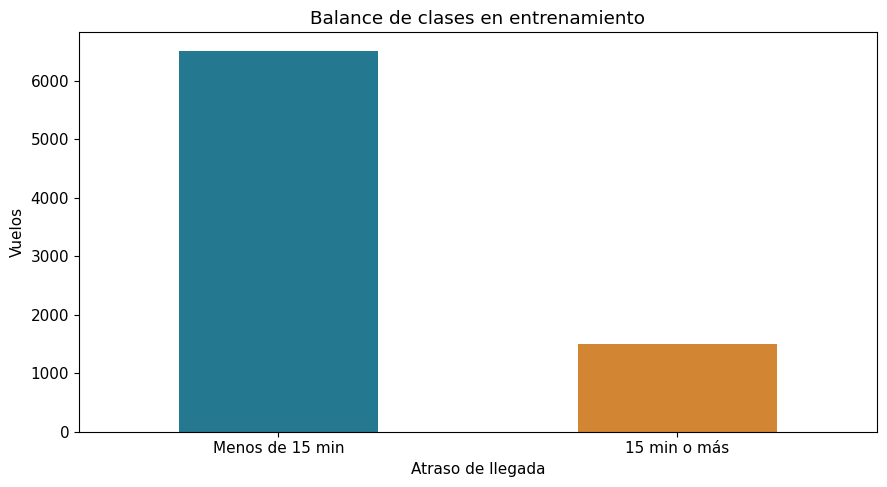

Proporción de atrasos: 18.66%.


In [10]:
conteo_clases = train[OBJETIVO].value_counts().sort_index()
balance = pd.DataFrame({'vuelos':conteo_clases,
                        'porcentaje':100*conteo_clases/len(train)})
balance.to_csv(REPORTES / 'balance_train.csv')
print(balance.round(3).to_string())
proporcion_atraso = float(train[OBJETIVO].mean())

ax = conteo_clases.rename(index={0:'Menos de 15 min',1:'15 min o más'}).plot.bar(
    rot=0, color=['#24788f','#d28532'])
ax.set(title='Balance de clases en entrenamiento', xlabel='Atraso de llegada', ylabel='Vuelos')
plt.tight_layout()
plt.savefig(GRAFICOS / '01_balance.png', dpi=150)
plt.show()
plt.close('all')
print(f'Proporción de atrasos: {proporcion_atraso:.2%}.')

## 11. Distribución del atraso de llegada

La primera vista muestra todo el rango. La segunda amplía el intervalo de -60 a
180 minutos para apreciar la concentración central. Se informa qué proporción de
train queda en ese intervalo: la limitación es visual y no elimina filas del CSV.

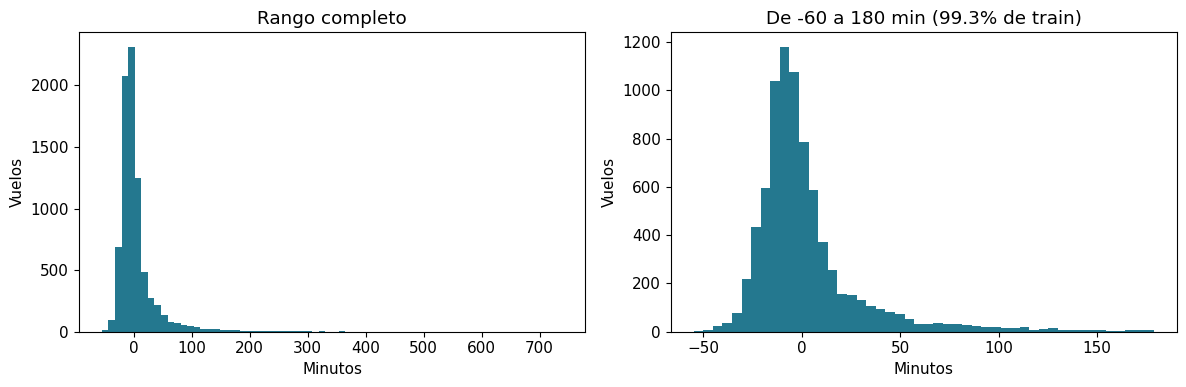

In [11]:
central = train.ARRIVAL_DELAY.between(-60,180)
fig, axes = plt.subplots(1,2,figsize=(12,4))
train.ARRIVAL_DELAY.plot.hist(bins=70, ax=axes[0], color='#24788f')
train.loc[central,'ARRIVAL_DELAY'].plot.hist(bins=48, ax=axes[1], color='#24788f')
axes[0].set(title='Rango completo', xlabel='Minutos', ylabel='Vuelos')
axes[1].set(title=f'De -60 a 180 min ({central.mean():.1%} de train)', xlabel='Minutos', ylabel='Vuelos')
fig.tight_layout()
fig.savefig(GRAFICOS / '02_atrasos.png', dpi=150)
plt.show()
plt.close(fig)

## 12. Comparar aerolíneas y meses

La media de una etiqueta 0/1 es la proporción de atrasos. Se muestran también los
conteos para interpretar cada tasa con su denominador. Las diferencias observadas
no controlan por ruta, horario o aeropuerto y no establecen causalidad.

AIRLINE
         vuelos  tasa_atraso
AIRLINE                     
AA          984       0.1778
AS          253       0.1344
B6          344       0.1890
DL         1265       0.1375
EV          767       0.2047
F9          122       0.2459
HA           89       0.1348
MQ          409       0.2592
NK          174       0.3161
OO          799       0.1790
UA          727       0.2146
US          277       0.1913
VX           92       0.2283
WN         1698       0.1837


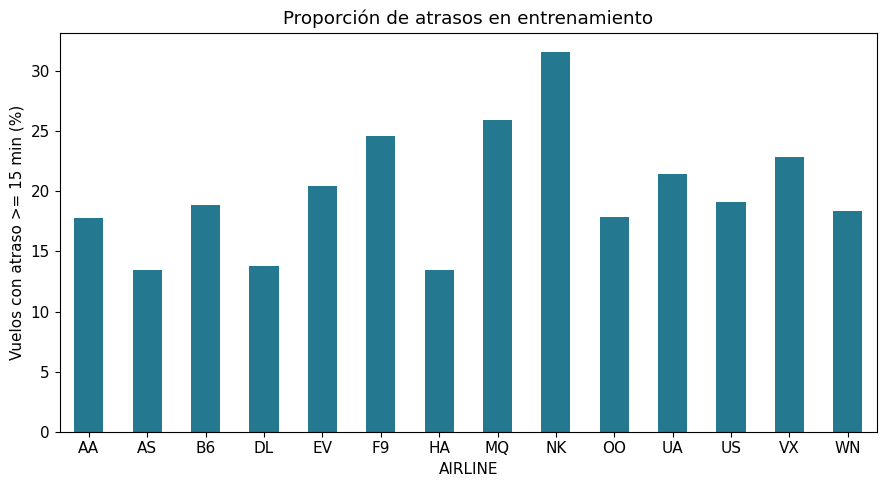

MONTH
       vuelos  tasa_atraso
MONTH                     
1         633       0.2117
2         629       0.2448
3         653       0.1975
4         685       0.1445
5         659       0.1851
6         711       0.2574
7         715       0.1944
8         711       0.2152
9         685       0.1285
10        682       0.1261
11        625       0.1408
12        612       0.1928


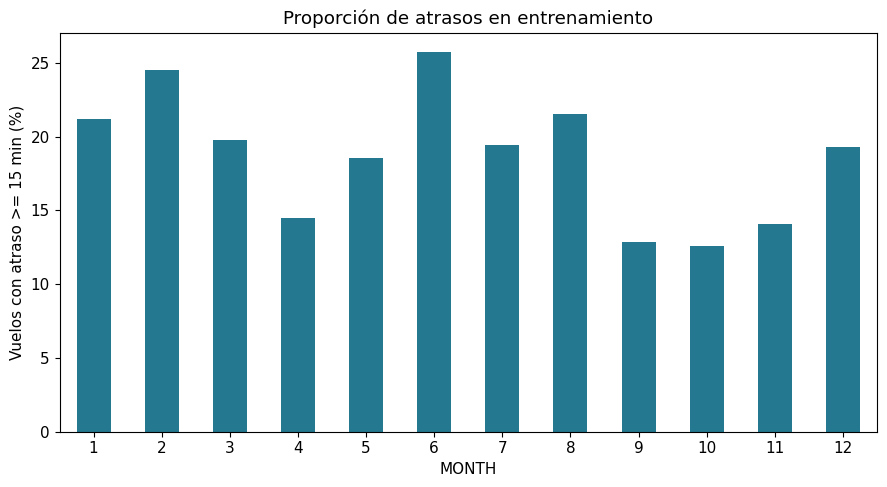

In [12]:
tablas_grupos = {}
for variable, nombre in [('AIRLINE','03_aerolineas'), ('MONTH','04_meses')]:
    tabla = train.groupby(variable)[OBJETIVO].agg(vuelos='size', tasa_atraso='mean')
    tablas_grupos[variable] = tabla
    tabla.to_csv(REPORTES / f'{nombre}.csv')
    print(variable)
    print(tabla.round(4).to_string())
    ax = (100*tabla.tasa_atraso).plot.bar(rot=0, color='#24788f')
    ax.set(title='Proporción de atrasos en entrenamiento', xlabel=variable,
           ylabel='Vuelos con atraso >= 15 min (%)')
    plt.tight_layout()
    plt.savefig(GRAFICOS / f'{nombre}.png', dpi=150)
    plt.show()
    plt.close('all')

## 13. Escalas y relaciones entre variables numéricas

La distancia está en millas y la duración programada en minutos. Sus escalas y
distribuciones son distintas. Para un modelo lineal puede ser conveniente estandarizar;
para árboles no suele ser necesario. En ambos casos la decisión se implementa en el pipeline.

La correlación de Pearson describe relaciones lineales. No implica causalidad ni mide
todas las relaciones predictivas. No se calculan correlaciones tratando los códigos
de aerolínea o aeropuerto como números.

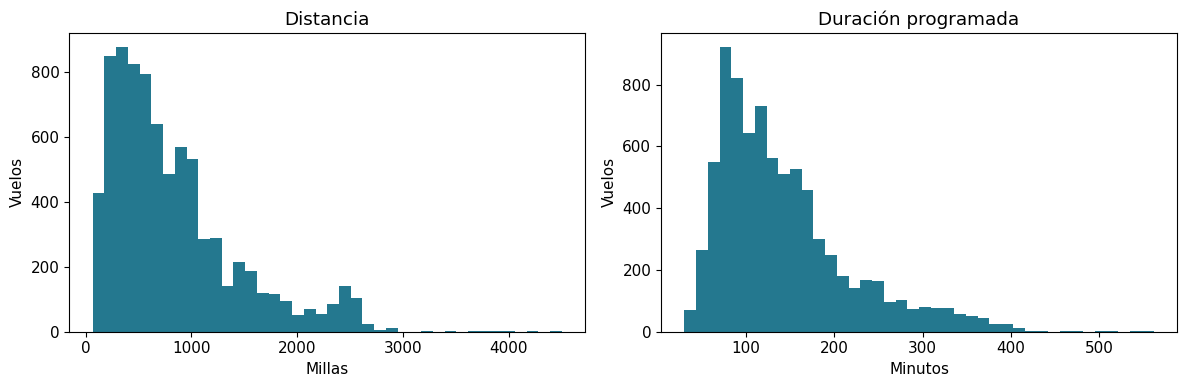

                         DISTANCE  SCHEDULED_TIME  SCHEDULED_DEPARTURE_MIN  ARRIVAL_DELAY_15
DISTANCE                    1.000           0.985                    0.004             0.008
SCHEDULED_TIME              0.985           1.000                   -0.004             0.009
SCHEDULED_DEPARTURE_MIN     0.004          -0.004                    1.000             0.117
ARRIVAL_DELAY_15            0.008           0.009                    0.117             1.000


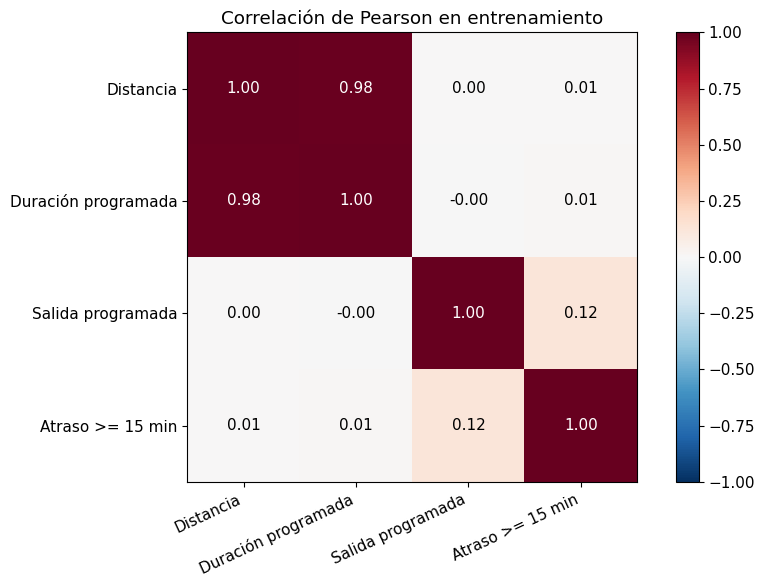

In [13]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
train.DISTANCE.plot.hist(bins=40,ax=axes[0],color='#24788f')
train.SCHEDULED_TIME.plot.hist(bins=40,ax=axes[1],color='#24788f')
axes[0].set(title='Distancia',xlabel='Millas',ylabel='Vuelos')
axes[1].set(title='Duración programada',xlabel='Minutos',ylabel='Vuelos')
fig.tight_layout()
fig.savefig(GRAFICOS / '05_distribuciones.png',dpi=150)
plt.show()
plt.close(fig)

correlacion = train[['DISTANCE','SCHEDULED_TIME','SCHEDULED_DEPARTURE_MIN',OBJETIVO]].corr()
correlacion.to_csv(REPORTES / 'correlaciones_train.csv')
print(correlacion.round(3).to_string())
fig, ax = plt.subplots(figsize=(9,6))
imagen = ax.imshow(correlacion,vmin=-1,vmax=1,cmap='RdBu_r')
etiquetas = ['Distancia','Duración programada','Salida programada','Atraso >= 15 min']
ax.set_xticks(range(4),etiquetas,rotation=25,ha='right')
ax.set_yticks(range(4),etiquetas)
for i in range(4):
    for j in range(4):
        valor = correlacion.iloc[i,j]
        ax.text(j,i,f'{valor:.2f}',ha='center',va='center',
                color='white' if abs(valor)>0.7 else 'black')
ax.set_title('Correlación de Pearson en entrenamiento')
fig.colorbar(imagen,ax=ax)
fig.tight_layout()
fig.savefig(GRAFICOS / '06_correlaciones.png',dpi=150)
plt.show()
plt.close(fig)

## 14. Selección final y prevención de fuga de información

Se excluyen las horas, duraciones y atrasos **reales**, así como cancelación, desvío
y causas del atraso: corresponden a información posterior al momento de predicción.
`YEAR` es constante en esta fuente. Número de vuelo y matrícula se omiten por simplicidad
y alta cardinalidad. La llegada programada podría usarse, pero se omite para mantener
un primer conjunto pequeño; no se clasifica como fuga.

El archivo `contrato_datos.json` registra la selección final. La entrada del modelo
se limita a la lista `features`; las columnas de auditoría no son predictores.

In [14]:
contrato = {
    'features':FEATURES, 'categoricas':CATEGORICAS, 'numericas':NUMERICAS,
    'target':OBJETIVO,
    'columnas_solo_auditoria':['SOURCE_ROW','FLIGHT_DATE','ARRIVAL_DELAY'],
    'poblacion':'Vuelos no cancelados ni desviados, con atraso de llegada observado',
    'momento_prediccion':'Antes de la salida programada',
    'regla_objetivo':'ARRIVAL_DELAY >= 15', 'semilla':SEMILLA,
}
(BASE / 'contrato_datos.json').write_text(
    json.dumps(contrato,indent=2,ensure_ascii=False),encoding='utf-8')
X_train = train[FEATURES]
y_train = train[OBJETIVO]
assert not set(FEATURES).intersection(contrato['columnas_solo_auditoria'])
assert X_train.shape[1] == 9 and len(CATEGORICAS) >= 1
print('Predictores:', FEATURES)
print('X_train:', X_train.shape, '| y_train:', y_train.shape)

Predictores: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE_MIN', 'SCHEDULED_TIME', 'DISTANCE']
X_train: (8000, 9) | y_train: (8000,)


## 15. Verificar los archivos exportados y registrar la ejecución

Se vuelven a leer los archivos de muestra, train y test para comprobar que su contenido
coincide con las tablas que se exportaron. Se recorre el CSV limpio exportado para
verificar cantidad de filas, ausencia de nulos, etiqueta y trazabilidad.

Se registran la versión del entorno y la huella del CSV original para documentar
la procedencia de los datos y permitir su reproducción.

In [15]:
for nombre, esperado in [('flights_muestra.csv',muestra),('train.csv',train),('test.csv',test)]:
    leido = pd.read_csv(DATOS / nombre)
    pd.testing.assert_frame_equal(leido,esperado.reset_index(drop=True),check_dtype=False)

filas_exportadas = 0
ultima_fila = 1
for bloque in pd.read_csv(ARCHIVO_LIMPIO,chunksize=250000):
    assert bloque.shape[1] == 13
    assert bloque.notna().all().all()
    assert bloque.SOURCE_ROW.is_unique and bloque.SOURCE_ROW.is_monotonic_increasing
    assert bloque.SOURCE_ROW.iloc[0] > ultima_fila
    assert bloque[OBJETIVO].eq(bloque.ARRIVAL_DELAY.ge(15)).all()
    assert bloque.SCHEDULED_DEPARTURE_MIN.between(0,1440).all()
    assert bloque.SCHEDULED_TIME.gt(0).all() and bloque.DISTANCE.gt(0).all()
    ultima_fila = bloque.SOURCE_ROW.iloc[-1]
    filas_exportadas += len(bloque)
assert filas_exportadas == limpios

sha = hashlib.sha256()
with RUTA_CSV.open('rb') as archivo:
    for parte in iter(lambda:archivo.read(8*1024*1024),b''):
        sha.update(parte)
resumen = {
    'filas_originales':total,'columnas_originales':len(columnas),
    'filas_limpias':limpios,'filas_excluidas':total-limpios,
    'muestra':len(muestra),'train':n_train,'test':n_test,
    'exclusiones':dict(conteos),'semilla':SEMILLA,'tamano_bloque':TAMANO_BLOQUE,
    'sha256_original':sha.hexdigest(), **versiones,
    'proporcion_atraso_train':proporcion_atraso,
    'correlacion_distancia_duracion':float(correlacion.loc['DISTANCE','SCHEDULED_TIME']),
    'verificacion_csv_exportados':True,
}
(REPORTES / 'resumen.json').write_text(json.dumps(resumen,indent=2,ensure_ascii=False),encoding='utf-8')
print('CSV limpio validado:',filas_exportadas,'filas.')
print('Muestra, train y test exportados: correctos.')
print('Contrato de datos y resumen de ejecución guardados.')

CSV limpio validado: 5714008 filas.
Muestra, train y test exportados: correctos.
Contrato de datos y resumen de ejecución guardados.


## 16. Conclusiones

El análisis permite construir una base con una etiqueta observada y predictores disponibles
antes de la salida. Las exclusiones responden a la población de estudio y a reglas de calidad
explícitas, sin rellenar atrasos desconocidos ni eliminar extremos válidos.

Los resultados siguientes se calculan a partir de esta ejecución.

In [16]:
print(f'1. Se procesaron {total:,} filas y {len(columnas)} columnas originales.')
print(f'2. Se conservaron {limpios:,} vuelos y se excluyeron {total-limpios:,}.')
print(f"   Cancelados: {conteos['cancelado_o_estado_invalido']:,}; desviados: {conteos['desviado_o_estado_invalido']:,}.")
print(f'3. La muestra contiene {len(muestra):,} vuelos: {n_train:,} en train y {n_test:,} en test.')
print(f'4. El {100*proporcion_atraso:.2f}% de train tiene atraso de llegada >= 15 minutos.')
print(f"5. La correlación entre distancia y duración programada es {correlacion.loc['DISTANCE','SCHEDULED_TIME']:.3f}.")
print('6. Se seleccionaron nueve predictores, incluidos tres categóricos, sin incorporar el atraso real.')

1. Se procesaron 5,819,079 filas y 31 columnas originales.
2. Se conservaron 5,714,008 vuelos y se excluyeron 105,071.
   Cancelados: 89,884; desviados: 15,187.
3. La muestra contiene 10,000 vuelos: 8,000 en train y 2,000 en test.
4. El 18.66% de train tiene atraso de llegada >= 15 minutos.
5. La correlación entre distancia y duración programada es 0.985.
6. Se seleccionaron nueve predictores, incluidos tres categóricos, sin incorporar el atraso real.


El desbalance de clases justifica evaluar el modelo con métricas que distingan detección
de atrasos y falsas alarmas. La alta relación entre distancia y duración se documenta,
sin eliminar automáticamente una de ellas. Los códigos IATA/BTS se mantienen diferenciados
y las categorías permanecen legibles hasta el preprocesamiento del modelo.

**Alcance:** los datos corresponden a 2015 y a vuelos que completan su ruta. Una separación
aleatoria dentro del mismo año no demuestra desempeño en años futuros, y puede existir
dependencia entre vuelos de rutas o fechas cercanas. Las diferencias entre aerolíneas y
meses son descriptivas, no causales. La evaluación predictiva se desarrolla por separado
en el notebook de entrenamiento utilizando el contrato y la partición generados aquí.